<a href="https://colab.research.google.com/github/luciusrapagna/Dados_Sheyla_Tese/blob/main/Dados_Sheyla_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-bio openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 51.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from matplotlib.patches import Ellipse

from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, permanova

In [39]:
from google.colab import files
uploaded = files.upload()

Saving Planilha_K_means_2_Dados Log_2.xlsx to Planilha_K_means_2_Dados Log_2 (2).xlsx


In [40]:
arquivo = "Planilha_K_means_2_Dados Log_2.xlsx"
df = pd.read_excel(arquivo)
df.head()

,Praia,Estacao_ano,Replica,Plásticos,Isopor,Borracha,Vidro,Fragmentos,Tecidos,Madeira,Não identificados,Cuidado Pessoal,Alumínio,Aerosol,Anel
0,Brava,Verão,1,1.740363,1.518514,0.30103,0.00000,0.00000,0.00000,0.000000,0.602060,0.60206,0.30103,0.00000,0.00000
1,Brava,Verão,2,1.146128,0.954243,0.00000,0.00000,0.00000,0.69897,0.778151,0.301030,0.00000,0.00000,0.00000,0.00000
2,Brava,Verão,3,1.361728,1.079181,0.00000,0.00000,0.00000,0.00000,0.000000,0.602060,0.00000,0.00000,0.00000,0.00000
3,Brava,Primavera,1,1.748188,2.082785,0.30103,1.00000,0.69897,0.69897,0.477121,0.954243,0.60206,0.00000,0.30103,0.60206
4,Brava,Primavera,2,1.518514,1.505150,0.00000,0.30103,0.60206,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.00000


In [41]:
print("Dimensão da tabela:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

Dimensão da tabela: (24, 15)

Colunas:
['Praia', 'Estacao_ano', 'Replica', 'Plásticos', 'Isopor', 'Borracha', 'Vidro', 'Fragmentos', 'Tecidos', 'Madeira', 'Não identificados', 'Cuidado Pessoal', 'Alumínio', 'Aerosol', 'Anel']


In [42]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("á", "a", regex=False)
    .str.replace("ã", "a", regex=False)
    .str.replace("â", "a", regex=False)
    .str.replace("é", "e", regex=False)
    .str.replace("ê", "e", regex=False)
    .str.replace("í", "i", regex=False)
    .str.replace("ó", "o", regex=False)
    .str.replace("ô", "o", regex=False)
    .str.replace("õ", "o", regex=False)
    .str.replace("ú", "u", regex=False)
    .str.replace("ç", "c", regex=False)
)

print(df.columns.tolist())

['Praia', 'Estacao_ano', 'Replica', 'Plasticos', 'Isopor', 'Borracha', 'Vidro', 'Fragmentos', 'Tecidos', 'Madeira', 'Nao_identificados', 'Cuidado_Pessoal', 'Aluminio', 'Aerosol', 'Anel']


In [43]:
meta_cols = ["Praia", "Estacao_ano", "Replica"]
X = df.drop(columns=meta_cols).copy()

X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Variáveis numéricas:")
print(X.columns.tolist())
X.head()

Variáveis numéricas:
['Plasticos', 'Isopor', 'Borracha', 'Vidro', 'Fragmentos', 'Tecidos', 'Madeira', 'Nao_identificados', 'Cuidado_Pessoal', 'Aluminio', 'Aerosol', 'Anel']


,Plasticos,Isopor,Borracha,Vidro,Fragmentos,Tecidos,Madeira,Nao_identificados,Cuidado_Pessoal,Aluminio,Aerosol,Anel
0,1.740363,1.518514,0.30103,0.00000,0.00000,0.00000,0.000000,0.602060,0.60206,0.30103,0.00000,0.00000
1,1.146128,0.954243,0.00000,0.00000,0.00000,0.69897,0.778151,0.301030,0.00000,0.00000,0.00000,0.00000
2,1.361728,1.079181,0.00000,0.00000,0.00000,0.00000,0.000000,0.602060,0.00000,0.00000,0.00000,0.00000
3,1.748188,2.082785,0.30103,1.00000,0.69897,0.69897,0.477121,0.954243,0.60206,0.00000,0.30103,0.60206
4,1.518514,1.505150,0.00000,0.30103,0.60206,0.00000,0.000000,0.000000,0.00000,0.00000,0.00000,0.00000


In [44]:
X_log = np.log1p(X)
X_log.head()

,Plasticos,Isopor,Borracha,Vidro,Fragmentos,Tecidos,Madeira,Nao_identificados,Cuidado_Pessoal,Aluminio,Aerosol,Anel
0,1.008090,0.923669,0.263156,0.000000,0.000000,0.000000,0.000000,0.471290,0.47129,0.263156,0.000000,0.00000
1,0.763665,0.670003,0.000000,0.000000,0.000000,0.530022,0.575574,0.263156,0.00000,0.000000,0.000000,0.00000
2,0.859393,0.731974,0.000000,0.000000,0.000000,0.000000,0.000000,0.471290,0.00000,0.000000,0.000000,0.00000
3,1.010942,1.125834,0.263156,0.693147,0.530022,0.530022,0.390095,0.670003,0.47129,0.000000,0.263156,0.47129
4,0.923669,0.918349,0.000000,0.263156,0.471290,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000


In [45]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

In [46]:
pca = PCA(n_components=2)
scores_array = pca.fit_transform(X_scaled)

In [47]:
scores = pd.DataFrame(scores_array, columns=["PC1", "PC2"])
scores["Praia"] = df["Praia"].values
scores["Estacao_ano"] = df["Estacao_ano"].values
scores["Replica"] = df["Replica"].values

scores.head()

,PC1,PC2,Praia,Estacao_ano,Replica
0,0.541540,-1.228291,Brava,Verão,1
1,-0.279622,0.232971,Brava,Verão,2
2,-1.146765,-0.175324,Brava,Verão,3
3,4.076430,3.080733,Brava,Primavera,1
4,-0.765626,1.337799,Brava,Primavera,2


In [48]:
var_exp = pca.explained_variance_ratio_ * 100

print(f"PC1 explica {var_exp[0]:.2f}% da variância")
print(f"PC2 explica {var_exp[1]:.2f}% da variância")
print(f"PC1 + PC2 explicam {var_exp[:2].sum():.2f}% da variância")

PC1 explica 62.04% da variância
PC2 explica 10.81% da variância
PC1 + PC2 explicam 72.85% da variância


In [49]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=["PC1", "PC2"]
)

loadings

,PC1,PC2
Plasticos,0.291999,-0.066066
Isopor,0.310022,0.068958
Borracha,0.335759,-0.107342
Vidro,0.141359,0.724724
Fragmentos,0.322427,0.057318
Tecidos,0.318944,0.163740
Madeira,0.279782,-0.054299
Nao_identificados,0.241018,-0.175571
Cuidado_Pessoal,0.325249,0.031228
Aluminio,0.219680,-0.614214


In [50]:
def draw_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    if len(x) < 3:
        return

    cov = np.cov(x, y)
    if np.linalg.det(cov) == 0:
        return

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )
    ax.add_patch(ellipse)

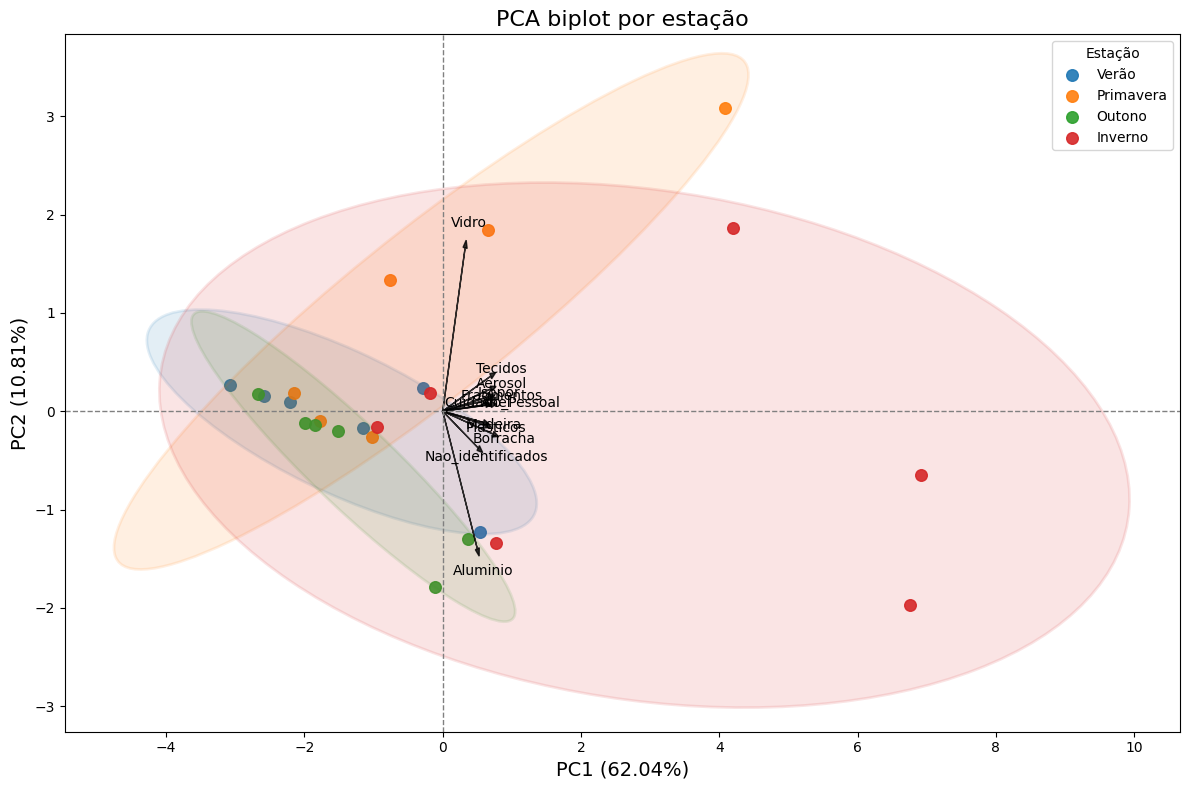

In [51]:
cores_estacao = {
    "Verão": "tab:blue",
    "Primavera": "tab:orange",
    "Outono": "tab:green",
    "Inverno": "tab:red"
}

fig, ax = plt.subplots(figsize=(12, 8))

for grupo, cor in cores_estacao.items():
    subset = scores[scores["Estacao_ano"] == grupo]
    if len(subset) == 0:
        continue

    ax.scatter(subset["PC1"], subset["PC2"], s=70, label=grupo, alpha=0.9)
    draw_ellipse(
        subset["PC1"], subset["PC2"], ax,
        edgecolor=cor, facecolor=cor, alpha=0.12, linewidth=2
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)

escala_seta = 2.4

for var in loadings.index:
    x = loadings.loc[var, "PC1"] * escala_seta
    y = loadings.loc[var, "PC2"] * escala_seta

    ax.arrow(0, 0, x, y, color="black", alpha=0.8,
             head_width=0.06, head_length=0.08, length_includes_head=True)
    ax.text(x * 1.10, y * 1.10, var, fontsize=10, ha="center", va="center")

ax.set_xlabel(f"PC1 ({var_exp[0]:.2f}%)", fontsize=14)
ax.set_ylabel(f"PC2 ({var_exp[1]:.2f}%)", fontsize=14)
ax.set_title("PCA biplot por estação", fontsize=16)
ax.legend(title="Estação")

plt.tight_layout()
plt.show()

In [52]:
def top_variaveis_por_eixo(loadings_df, eixo="PC1", n=4):
    s = loadings_df[eixo].abs().sort_values(ascending=False).head(n)
    return list(s.index)

top_pc1 = top_variaveis_por_eixo(loadings, "PC1", 4)
top_pc2 = top_variaveis_por_eixo(loadings, "PC2", 4)

print("Variáveis mais importantes em PC1:", top_pc1)
print("Variáveis mais importantes em PC2:", top_pc2)

Variáveis mais importantes em PC1: ['Borracha', 'Cuidado_Pessoal', 'Fragmentos', 'Aerosol']
Variáveis mais importantes em PC2: ['Vidro', 'Aluminio', 'Nao_identificados', 'Tecidos']


In [53]:
inercias = []
silhuetas = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, labels))

print("Inércias:", inercias)
print("Silhuetas:", silhuetas)

Inércias: [140.1094362546681, 107.49687721819392, 82.47062396887733, 67.62285953235465, 54.58193802212702]
Silhuetas: [np.float64(0.5403919825767793), np.float64(0.249562963521926), np.float64(0.2621328011670582), np.float64(0.2651704018565251), np.float64(0.2876649822653958)]


In [54]:
inercias = []
silhuetas = []
k_range = range(2, 7)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, labels))

print("Inércias:", inercias)
print("Silhuetas:", silhuetas)

Inércias: [140.1094362546681, 107.49687721819392, 82.47062396887733, 67.62285953235465, 54.58193802212702]
Silhuetas: [np.float64(0.5403919825767793), np.float64(0.249562963521926), np.float64(0.2621328011670582), np.float64(0.2651704018565251), np.float64(0.2876649822653958)]


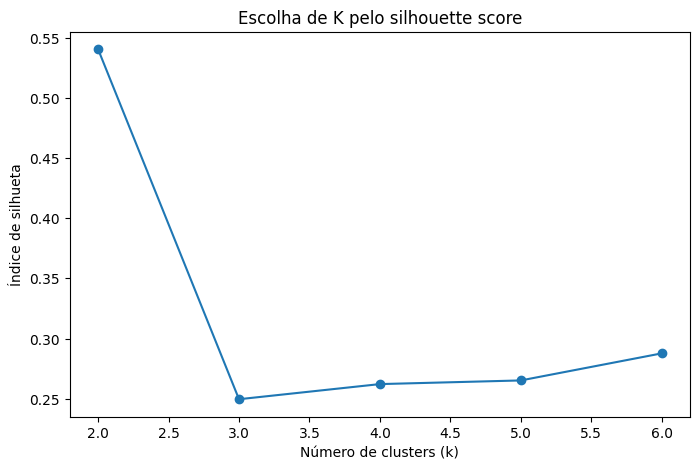

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhuetas, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Índice de silhueta")
plt.title("Escolha de K pelo silhouette score")
plt.show()

In [56]:
k_ideal = list(k_range)[int(np.argmax(silhuetas))]
print("K ideal:", k_ideal)

K ideal: 2


In [57]:
kmeans = KMeans(n_clusters=k_ideal, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
scores["Cluster"] = clusters

df[["Praia", "Estacao_ano", "Replica", "Cluster"]].head()

,Praia,Estacao_ano,Replica,Cluster
0,Brava,Verão,1,0
1,Brava,Verão,2,0
2,Brava,Verão,3,0
3,Brava,Primavera,1,1
4,Brava,Primavera,2,0


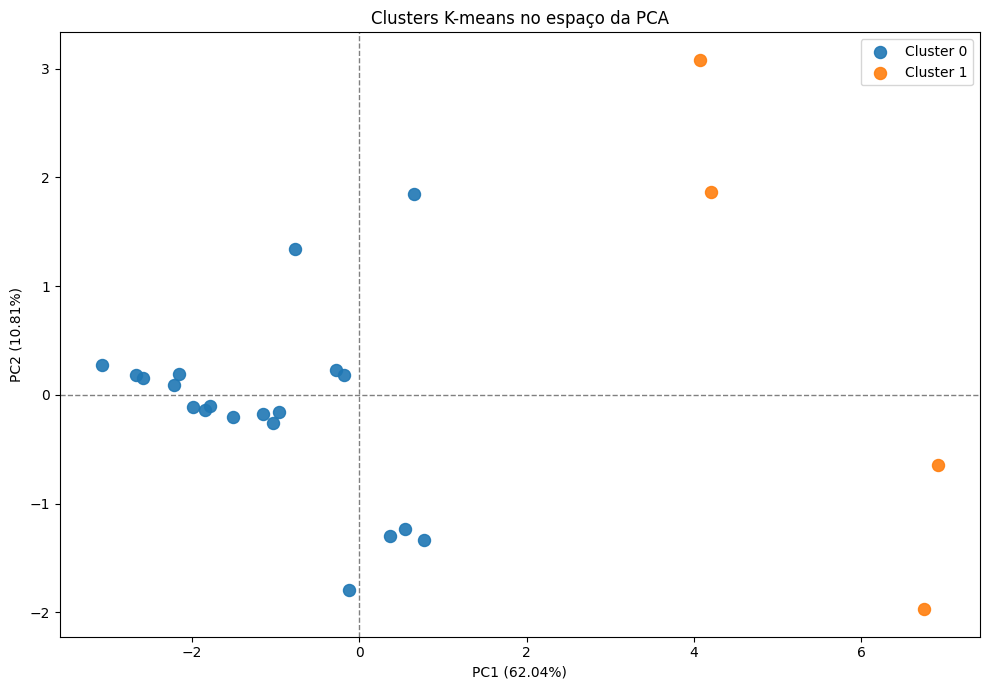

In [58]:
fig, ax = plt.subplots(figsize=(10, 7))

for cl in sorted(scores["Cluster"].unique()):
    subset = scores[scores["Cluster"] == cl]
    ax.scatter(subset["PC1"], subset["PC2"], s=75, label=f"Cluster {cl}", alpha=0.9)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.axvline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel(f"PC1 ({var_exp[0]:.2f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.2f}%)")
ax.set_title("Clusters K-means no espaço da PCA")
ax.legend()

plt.tight_layout()
plt.show()

In [59]:
perfil_clusters = df.groupby("Cluster")[X.columns].mean().round(2)
perfil_clusters

,Plasticos,Isopor,Borracha,Vidro,Fragmentos,Tecidos,Madeira,Nao_identificados,Cuidado_Pessoal,Aluminio,Aerosol,Anel
Cluster,,,,,,,,,,,,
0,1.12,0.64,0.11,0.05,0.16,0.07,0.17,0.34,0.03,0.07,0.00,0.02
1,2.14,2.35,0.86,0.37,1.27,0.88,1.03,0.79,0.78,0.29,0.42,0.51


In [60]:
cluster_praia = pd.crosstab(df["Cluster"], df["Praia"])
cluster_estacao = pd.crosstab(df["Cluster"], df["Estacao_ano"])

print("Cluster x Praia")
print(cluster_praia)

print("\nCluster x Estação")
print(cluster_estacao)

Cluster x Praia
Praia    Barava  Brava  Ilha
Cluster                     
0             3      5    12
1             0      4     0

Cluster x Estação
Estacao_ano  Inverno  Outono  Primavera  Verão
Cluster                                       
0                  3       6          5      6
1                  3       0          1      0


In [61]:
bray = pdist(X.values, metric="braycurtis")
bray_square = squareform(bray)

dm = DistanceMatrix(bray_square, ids=df.index.astype(str).tolist())
print(dm)

24x24 distance matrix
IDs:
'0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', ...
Data:
[[0.         0.46298888 0.24939333 0.34431792 0.32746271 0.25205833
  0.13508041 0.62084144 0.39568205 0.43318152 0.48583586 0.3789396
  0.78752511 0.8446931  1.         0.33363191 0.58598335 0.49028131
  0.34139097 0.54843134 0.82782175 0.22947165 0.55922305 0.33062325]
 [0.46298888 0.         0.3061031  0.46384452 0.46180747 0.42441613
  0.40325375 0.42728507 0.37674414 0.53509847 0.58105283 0.45005592
  0.73125812 0.56464466 1.         0.28662532 0.49152658 0.44525898
  0.4661496  0.45957637 0.78091811 0.35595869 0.35085026 0.31629317]
 [0.24939333 0.3061031  0.         0.51349182 0.29956783 0.31779248
  0.15622629 0.45414291 0.16230506 0.61602417 0.65577297 0.54819324
  0.66965422 0.76850856 1.         0.11613224 0.39419829 0.27444518
  0.38251284 0.34641959 0.72891533 0.28327927 0.51406939 0.11192603]
 [0.34431792 0.46384452 0.51349182 0.         0.41362025 0.287547

In [62]:
permanova_praia = permanova(dm, grouping=df["Praia"].set_axis(dm.ids), permutations=999)
print(permanova_praia)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      24
number of groups                  3
test statistic             3.479071
p-value                       0.005
number of permutations          999
Name: PERMANOVA results, dtype: object


In [63]:
permanova_estacao = permanova(dm, grouping=df["Estacao_ano"].set_axis(dm.ids), permutations=999)
print(permanova_estacao)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      24
number of groups                  4
test statistic             1.900999
p-value                       0.043
number of permutations          999
Name: PERMANOVA results, dtype: object


In [64]:
pseudoF_praia = permanova_praia["test statistic"]
p_praia = permanova_praia["p-value"]

pseudoF_estacao = permanova_estacao["test statistic"]
p_estacao = permanova_estacao["p-value"]

print("Praia:", pseudoF_praia, p_praia)
print("Estação:", pseudoF_estacao, p_estacao)

Praia: 3.479071184872421 0.005
Estação: 1.9009994885062154 0.043


In [65]:
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(4).index.tolist()
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(4).index.tolist()

texto_resultados = f"""
A análise de componentes principais (PCA) mostrou que os dois primeiros eixos explicaram
{var_exp[0] + var_exp[1]:.2f}% da variação total dos dados, sendo {var_exp[0]:.2f}% no primeiro eixo
e {var_exp[1]:.2f}% no segundo. As variáveis com maior contribuição para a ordenação em PC1 foram
{", ".join(top_pc1)}, enquanto PC2 foi mais influenciado por {", ".join(top_pc2)}.

A análise de agrupamento K-means indicou {k_ideal} grupos como a solução mais adequada,
com base no maior índice de silhueta. Os clusters formados apresentaram perfis distintos,
com diferenças nas categorias predominantes de resíduos entre os agrupamentos.

A PERMANOVA baseada na distância de Bray-Curtis indicou
{"diferença significativa" if p_praia < 0.05 else "ausência de diferença significativa"}
entre as praias (pseudo-F = {pseudoF_praia:.3f}; p = {p_praia:.4f}) e
{"diferença significativa" if p_estacao < 0.05 else "ausência de diferença significativa"}
entre as estações do ano (pseudo-F = {pseudoF_estacao:.3f}; p = {p_estacao:.4f}).
"""

print(texto_resultados)


A análise de componentes principais (PCA) mostrou que os dois primeiros eixos explicaram
72.85% da variação total dos dados, sendo 62.04% no primeiro eixo
e 10.81% no segundo. As variáveis com maior contribuição para a ordenação em PC1 foram
Borracha, Cuidado_Pessoal, Fragmentos, Aerosol, enquanto PC2 foi mais influenciado por Vidro, Aluminio, Nao_identificados, Tecidos.

A análise de agrupamento K-means indicou 2 grupos como a solução mais adequada,
com base no maior índice de silhueta. Os clusters formados apresentaram perfis distintos,
com diferenças nas categorias predominantes de resíduos entre os agrupamentos.

A PERMANOVA baseada na distância de Bray-Curtis indicou
diferença significativa
entre as praias (pseudo-F = 3.479; p = 0.0050) e
diferença significativa
entre as estações do ano (pseudo-F = 1.901; p = 0.0430).

